In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
zbest = Table(fitsio.read('/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/blanc/v2/LRG/alltiles_LRGzinfo.fits'))
print(len(zbest))

79651


In [4]:
zbest[:1]

TARGETID,CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,NUMEXP,NUMTILE,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,NUMTARGET,PRIORITY,SUBPRIORITY,OBSCONDITIONS,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,PRIORITY_INIT,NUMOBS_INIT,RELEASE,BRICKID,BRICKNAME,BRICK_OBJID,BLOBDIST,FIBERFLUX_IVAR_G,FIBERFLUX_IVAR_R,FIBERFLUX_IVAR_Z,DESI_TARGET,BGS_TARGET,MWS_TARGET,HPXPIXEL,NUM_ITER,FIBER_X,FIBER_Y,MEAN_DELTA_X,MEAN_DELTA_Y,FIBER_RA,FIBER_DEC,NIGHT,EXPID,MJD,TILEID,COADD_NUMEXP,RMS_DELTA_X,RMS_DELTA_Y,FIRST_NIGHT,LAST_NIGHT,NUM_NIGHT,FIRST_EXPID,LAST_EXPID,NUM_EXPID,FIRST_TILEID,LAST_TILEID,NUM_TILEID,FIRST_FIBER,LAST_FIBER,NUM_FIBER,EXPS,B_DEPTH,R_DEPTH,Z_DEPTH,B_DEPTH_EBVAIR,R_DEPTH_EBVAIR,Z_DEPTH_EBVAIR,ELGTSNR,BGSTSNR,LRGTSNR,QSOTSNR,subset,elgqso_weight,TARGETS
int64,float64,float64,float64,float64,int64,int64,str6,str20,int64,float64,int32,int32,int16,int32,int64,int32,int32,float64,float64,float32,float32,float32,float32,int64,uint8,str3,float32,float32,int16,int32,float64,int32,str4,float32,float32,float32,float32,float32,float32,int64,str2,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,str1,int64,int64,int64,int64,int64,int32,int32,str8,int32,float32,float32,float32,float32,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,int32,int32,float64,int32,int16,float64,float64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,str167,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str8,float64,str7
39627623046842657,8856.747344627976,475.77814891369235 .. -11.038078176618725,0.3405648212513373,4.665694017267479e-05,0,7902,GALAXY,,10,231.37385591492057,0,1,0,494,494,358,0,66.46968973338203,-6.732241342911616,0.0,0.0,2020.9624,5400.0,1152921504715898985,1,TGT,53.470455,-376.47275,16959,2000,0.6604134575473025,5,SER,6.448931,29.011358,62.9603,275.0878,53.334736,15.9458,0,,0.0,0.0,0.0,0.0,0.05547338,86.66802,55.530643,1.9522387,8.782401,19.05952,1.9522387,8.782401,19.05952,0,4.9821424,1.3058442,-0.022658674,-0.010907631,S,1152921504715898985,131074,0,2000,1,9010,291820,0664m067,2337,1e+20,1e+20,1e+20,1e+20,0,0,0,999999,2,53.453,-376.363,-0.001,0.0022500000000000003,66.46969361618913,-6.732233087227945,20201220,69037,59204.1933784,80612,4,0.0035355339059327377,0.0029580398915498084,20201220,20201220,1,69037,69040,4,80612,80612,1,358,358,1,"69037,69038,69039,69040",152.19999885559082,256.0999984741211,330.0,107.12174034118652,205.22063064575195,291.6577377319336,171.97615742497146,2242.291923522949,14.19109775684774,12.576469212770462,20201220,1.0,BGS+MWS


In [5]:
mask = zbest['subset']=='deep'
print(np.sum(mask))
mask &= zbest['TARGETS']=='QSO+LRG'
print(np.sum(mask))

zbest = zbest[mask]
print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

14530
10113
10113
10113


In [6]:
t = Table()
t['TILEID'], t['count'] = np.unique(zbest['TILEID'], return_counts=True)
t

TILEID,count
int32,int64
80605,2117
80607,1922
80609,2125
80620,2049
80622,1900


/global/common/software/desi/cori/desiconda/20200801-1.4.0-spec/conda/lib/python3.8/site-packages/numpy/core/_asarray.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order)


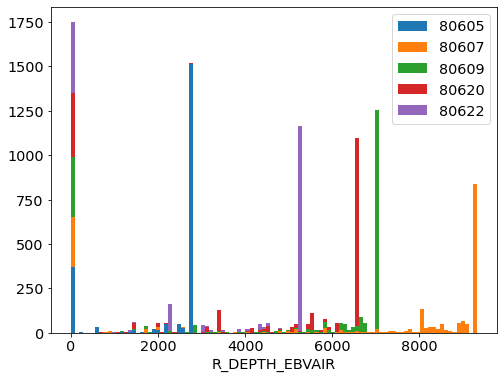

In [7]:
plt.figure(figsize=(8, 6))
tileid_list = np.unique(zbest['TILEID'])
tmp = []
for tileid in tileid_list:
    mask = zbest['TILEID']==tileid
    tmp.append(zbest['R_DEPTH_EBVAIR'][mask])
plt.hist(tmp, 100, label=tileid_list, range=(0, zbest['R_DEPTH_EBVAIR'].max()), histtype='barstacked')
plt.xlabel('R_DEPTH_EBVAIR')
plt.legend()
plt.show()

In [8]:
# Remove FIBERSTATUS!=0 fibers
mask = zbest['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

# Remove "no data" fibers
mask = zbest['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

# Require a minimum depth for the deep coadd
min_depth = 4000.
mask = zbest['R_DEPTH_EBVAIR']>min_depth
print(np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
zbest = zbest[mask]

print(len(zbest))

FIBERSTATUS 8364 1749 0.1729457134381489
No data 8364 0 0.0
5942 2422 0.7104256336681014
5942


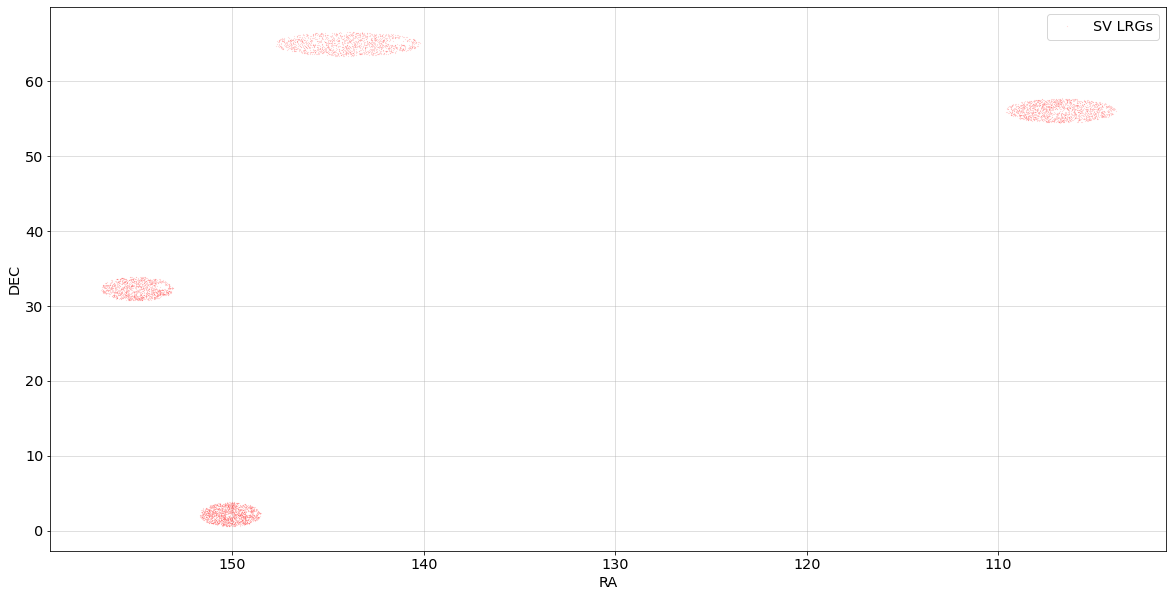

In [9]:
# mask = np.ones(len(zbest), dtype=bool)
plt.figure(figsize=(20, 10))
plt.plot(zbest['TARGET_RA'], zbest['TARGET_DEC'], 'r.', ms=.1, label='SV LRGs')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

__Add sweep columns__

In [10]:
# Snippets taken from desitarget

from desitarget.targets import encode_targetid

def decode_sweep_name(sweepname):
    sweepname = os.path.basename(sweepname)

    ramin, ramax = float(sweepname[6:9]), float(sweepname[14:17])
    decmin, decmax = float(sweepname[10:13]), float(sweepname[18:21])

    if sweepname[9] == 'm':
        decmin *= -1
    if sweepname[17] == 'm':
        decmax *= -1

    return [ramin, ramax, decmin, decmax]

def is_in_box(objs, radecbox, ra_col='RA', dec_col='DEC'):

    ramin, ramax, decmin, decmax = radecbox

    # ADM check for some common mistakes.
    if decmin < -90. or decmax > 90. or decmax <= decmin or ramax <= ramin:
        msg = "Strange input: [ramin, ramax, decmin, decmax] = {}".format(radecbox)
        log.critical(msg)
        raise ValueError(msg)

    ii = ((objs[ra_col] >= ramin) & (objs[ra_col] < ramax)
          & (objs[dec_col] >= decmin) & (objs[dec_col] < decmax))

    return ii

In [11]:
ls_columns = ['MW_TRANSMISSION_G', 'MW_TRANSMISSION_R', 'MW_TRANSMISSION_Z', 'MW_TRANSMISSION_W1', 'MW_TRANSMISSION_W2']


# Ignore any possible north/south overlap

sweep_fn_list = []
for field in ['north', 'south']:
    sweep_dir = '/global/cfs/cdirs/cosmo/data/legacysurvey/dr9/{}/sweep/9.0'.format(field)
    sweep_fn_list += sorted(glob.glob(os.path.join(sweep_dir, '*.fits')))
sweep_fn_list = np.array(sweep_fn_list)

sweep_radec_list = [decode_sweep_name(sweep_fn) for sweep_fn in sweep_fn_list]
mask = np.array([np.any(is_in_box(zbest, sweep_radec, ra_col='TARGET_RA', dec_col='TARGET_DEC')) for sweep_radec in sweep_radec_list])
print(np.sum(mask))
sweep_fn_list = sweep_fn_list[mask]

ls_stack = []
for sweep_fn in sweep_fn_list:
    ls = Table(fitsio.read(sweep_fn, columns=['OBJID', 'BRICKID', 'RELEASE']))
    targetid = encode_targetid(ls['OBJID'], ls['BRICKID'], ls['RELEASE'])
    idx = np.where(np.in1d(targetid, zbest['TARGETID']))[0]
    if len(idx)==0:
        continue
    targetid = targetid[idx]
    ls = Table(fitsio.read(sweep_fn, rows=idx, columns=ls_columns))
    ls['TARGETID'] = targetid
    # if '/south/sweep/' in sweep_fn:
    #     ls['field'] = 'south'
    # else:
    #     ls['field'] = 'north'
    # pz_fn = sweep_fn.replace('sweep/9.0/', 'sweep/9.0-photo-z/').replace('.fits', '-pz.fits')
    # pz = Table(fitsio.read(pz_fn, rows=idx))
    # pz.remove_columns(['OBJID', 'BRICKID', 'RELEASE'])
    # ls = hstack([ls, pz])
    ls_stack.append(ls)
ls = vstack(ls_stack)
print(len(zbest), len(ls))

# # This only works if the objects are unique
# _, idx1, idx2 = np.intersect1d(zbest['TARGETID'], ls['TARGETID'], return_indices=True)
# print(len(zbest), len(idx1), len(zbest)-len(idx1))
# zbest = zbest[idx1]
# ls = ls[idx2]

zbest = join(zbest, ls, keys='TARGETID')

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    zbest['gmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_G']/zbest['MW_TRANSMISSION_G'])
    zbest['rmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_R']/zbest['MW_TRANSMISSION_R'])
    zbest['zmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_Z']/zbest['MW_TRANSMISSION_Z'])
    zbest['w1mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W1']/zbest['MW_TRANSMISSION_W1'])
    zbest['w2mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W2']/zbest['MW_TRANSMISSION_W2'])
    zbest['gfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_G']/zbest['MW_TRANSMISSION_G'])
    zbest['rfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_R']/zbest['MW_TRANSMISSION_R'])
    zbest['zfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_Z']/zbest['MW_TRANSMISSION_Z'])

10
5942 5942


In [12]:
lrg_opt = zbest['SV1_DESI_TARGET'] & 2**3>0
lrg_ir = zbest['SV1_DESI_TARGET'] & 2**4>0
lrg_sv = (zbest['SV1_DESI_TARGET'] & 2**0>0)
print(np.sum(lrg_opt))
print(np.sum(lrg_ir))
print(np.sum(lrg_sv))
print()

ts_qso = (zbest['SV1_DESI_TARGET'] & 2**2>0)
print(np.sum(ts_qso))
print(np.sum(ts_qso & lrg_sv))
print(np.sum(ts_qso & lrg_opt))

1538
1589
5942

133
133
12


In [13]:
mask_zwarn = zbest['ZWARN']==0
print(np.sum((~mask_zwarn) & lrg_opt), np.sum((~mask_zwarn) & lrg_opt)/np.sum(lrg_opt))
print(np.sum((~mask_zwarn) & lrg_ir), np.sum((~mask_zwarn) & lrg_ir)/np.sum(lrg_ir))
print(np.sum((~mask_zwarn) & lrg_sv), np.sum((~mask_zwarn) & lrg_sv)/np.sum(lrg_sv))

3 0.0019505851755526658
7 0.004405286343612335
49 0.008246381689666779


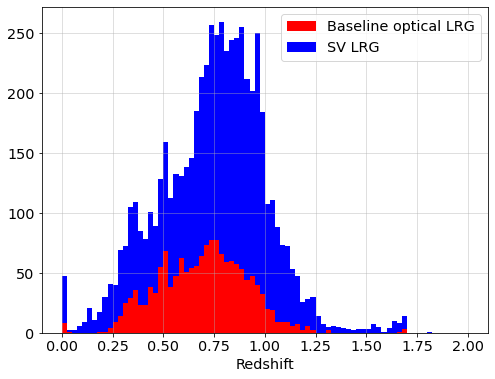

In [14]:
plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt & mask_zwarn], bins=80, range=(0, 2.0), color='red', label='Baseline optical LRG', zorder=1)
plt.hist(zbest['Z'][lrg_sv & mask_zwarn], bins=80, range=(0, 2.0), color='blue', label='SV LRG', zorder=0)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.show()

No ZWARN cut:


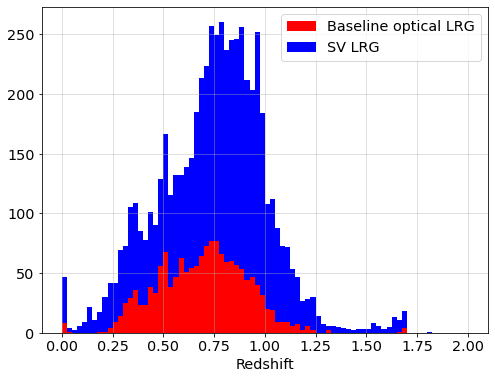

In [15]:
print('No ZWARN cut:')
plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt], bins=80, range=(0, 2.0), color='red', label='Baseline optical LRG', zorder=1)
plt.hist(zbest['Z'][lrg_sv], bins=80, range=(0, 2.0), color='blue', label='SV LRG', zorder=0)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.show()

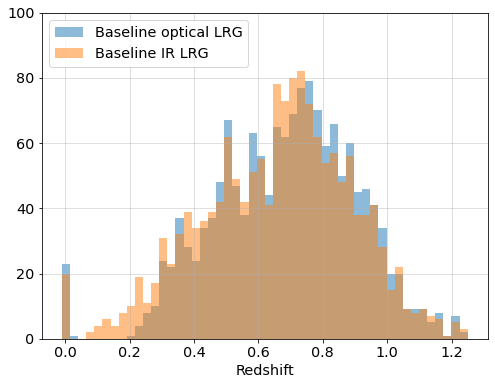

In [59]:
plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt & mask_zwarn], bins=50, range=(-0.01, 1.25), label='Baseline optical LRG', alpha=0.5)
plt.hist(zbest['Z'][lrg_ir & mask_zwarn], bins=50, range=(-0.01, 1.25), label='Baseline IR LRG', alpha=0.5)
plt.xlabel('Redshift')
plt.legend(loc='upper left')
plt.grid(alpha=0.5)
plt.ylim(ymax=100)
plt.show()

In [52]:
print('Z > 1.5 LRG targets:')
mask = (zbest['Z']>1.5) & lrg_sv
print('{:.1f}%'.format(np.sum(mask)/np.sum(lrg_sv)*100))

t = Table()
t['tileid'], t['counts'] = np.unique(zbest['TILEID'][mask], return_counts=True)
t['frac (%)'] = t['counts']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
# t.sort('counts')
t

Z > 1.5 LRG targets:
1.2%


tileid,counts,frac (%)
int32,int64,float64
80607,16,22.9
80609,32,45.7
80620,10,14.3
80622,12,17.1


--------
# Low-z (z<0.3) contamination

In [53]:
mask_lowz = (zbest['Z']<0.3) & (zbest['SPECTYPE']!='STAR')

mask = lrg_opt & mask_zwarn
print('LRG_OPT: {:.1f}%'.format(np.sum(mask & mask_lowz)/np.sum(mask)*100))

mask = lrg_ir & mask_zwarn
print('LRG_IR: {:.1f}%'.format(np.sum(mask & mask_lowz)/np.sum(mask)*100))

mask = lrg_sv & mask_zwarn
print('LRG_SV: {:.1f}%'.format(np.sum(mask & mask_lowz)/np.sum(mask)*100))

LRG_OPT: 2.0%
LRG_IR: 5.7%
LRG_SV: 4.2%


__Reintroduce g-band-based low-z cuts to the low-z selection__

In [62]:
# South
lowz_cut_south = (zbest['gmag'] - zbest['w1mag'] > 2.6) & (zbest['gmag'] - zbest['rmag'] > 1.4) # low-z cut
lowz_cut_south |= (zbest['rmag']-zbest['w1mag']) > 1.8                   # ignore low-z cut for faint objects
# print(np.sum(lowz_cut_south))

# North
lowz_cut_north = (zbest['gmag'] - zbest['w1mag'] > 2.67) & (zbest['gmag'] - zbest['rmag'] > 1.45)  # low-z cut
lowz_cut_north |= (zbest['rmag']-zbest['w1mag']) > 1.85                         # ignore low-z cut for faint objects
# print(np.sum(lowz_cut_north))

mask_south = zbest['PHOTSYS']=='S'
# print(np.sum(mask_south))
mask_north = zbest['PHOTSYS']=='N'
# print(np.sum(mask_north))
lowz_cut = (lowz_cut_south & mask_south) | (lowz_cut_north & mask_north)
# print(np.sum(lowz_cut))

print(np.sum(lrg_ir)-np.sum(lrg_ir & lowz_cut), (np.sum(lrg_ir)-np.sum(lrg_ir & lowz_cut))/np.sum(lrg_ir))
print(np.sum(lrg_opt)-np.sum(lrg_opt & lowz_cut), (np.sum(lrg_opt)-np.sum(lrg_opt & lowz_cut))/np.sum(lrg_opt))

100 0.06293266205160478
0 0.0


LRG_IR: 2.7%


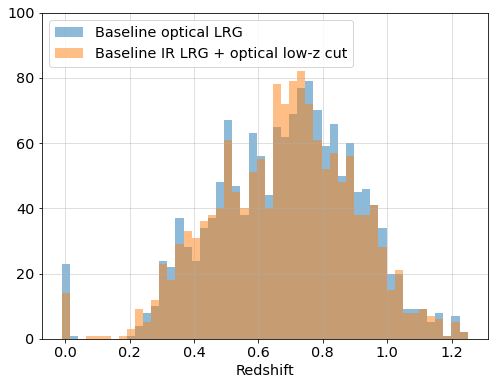

In [63]:
mask = lrg_ir & mask_zwarn & lowz_cut
print('LRG_IR: {:.1f}%'.format(np.sum(mask & mask_lowz)/np.sum(mask)*100))

plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt & mask_zwarn], bins=50, range=(-0.01, 1.25), label='Baseline optical LRG', alpha=0.5)
plt.hist(zbest['Z'][lrg_ir & mask_zwarn & lowz_cut], bins=50, range=(-0.01, 1.25), label='Baseline IR LRG + optical low-z cut', alpha=0.5)
plt.xlabel('Redshift')
plt.legend(loc='upper left')
plt.grid(alpha=0.5)
plt.ylim(ymax=100)
plt.show()

--------
# Stellar contamination

In [18]:
print('LRG_OPT:')
mask = lrg_opt & mask_zwarn
print(np.sum(mask))
t = Table()
t['type'], t['counts'] = np.unique(zbest['SPECTYPE'][mask], return_counts=True)
t['frac (%)'] = t['counts']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
# t.sort('counts')
t

LRG_OPT:
1535


type,counts,frac (%)
str6,int64,float64
GALAXY,1506,98.1
QSO,6,0.4
STAR,23,1.5


In [19]:
print('LRG_IR:')
mask = lrg_ir & mask_zwarn
print(np.sum(mask))
t = Table()
t['type'], t['counts'] = np.unique(zbest['SPECTYPE'][mask], return_counts=True)
t['frac (%)'] = t['counts']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
# t.sort('counts')
t

LRG_IR:
1582


type,counts,frac (%)
str6,int64,float64
GALAXY,1521,96.1
QSO,41,2.6
STAR,20,1.3


In [20]:
print('LRG_SV:')
mask = lrg_sv & mask_zwarn
print(np.sum(mask))
t = Table()
t['type'], t['counts'] = np.unique(zbest['SPECTYPE'][mask], return_counts=True)
t['frac (%)'] = t['counts']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
# t.sort('counts')
t

LRG_SV:
5893


type,counts,frac (%)
str6,int64,float64
GALAXY,5676,96.3
QSO,112,1.9
STAR,105,1.8


In [24]:
print('Stars:')
mask = (zbest['SPECTYPE']=='STAR') & lrg_sv
print('{:.1f}%'.format(np.sum(mask)/np.sum(lrg_sv)*100))

t = Table()
t['tileid'], t['counts'] = np.unique(zbest['TILEID'], return_counts=True)
t1 = Table()
t1['tileid'], t1['counts_star'] = np.unique(zbest['TILEID'][mask], return_counts=True)
t = join(t, t1)
t['star frac (%)'] = t['counts_star']/t['counts']*100
t['star frac (%)'].format = '%.1f'
# t.sort('counts')
t

Stars:
1.8%


tileid,counts,counts_star,star frac (%)
int32,int64,int64,float64
80607,1582,62,3.9
80609,1684,10,0.6
80620,1434,20,1.4
80622,1242,13,1.0


In [25]:
mask_star = zbest['SPECTYPE']=='STAR'
mask_gal = zbest['SPECTYPE']=='GALAXY'
mask_qso = zbest['SPECTYPE']=='QSO'

In [26]:
mask = lrg_sv & mask_star & mask_zwarn
print(np.sum(mask))
mask1 = mask & ((zbest['MASKBITS'] & 2**11>0) | (zbest['MASKBITS'] & 2**8>0))
print(np.sum(mask1))

105
49


In [27]:
mask = lrg_opt & mask_star & mask_zwarn
print(np.sum(mask))
mask1 = mask & ((zbest['MASKBITS'] & 2**11>0) | (zbest['MASKBITS'] & 2**8>0))
print(np.sum(mask1))

23
11


In [28]:
mask = lrg_sv & mask_star & mask_zwarn
zbest[mask]

TARGETID,CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,NUMEXP,NUMTILE,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,NUMTARGET,PRIORITY,SUBPRIORITY,OBSCONDITIONS,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,PRIORITY_INIT,NUMOBS_INIT,RELEASE,BRICKID,BRICKNAME,BRICK_OBJID,BLOBDIST,FIBERFLUX_IVAR_G,FIBERFLUX_IVAR_R,FIBERFLUX_IVAR_Z,DESI_TARGET,BGS_TARGET,MWS_TARGET,HPXPIXEL,NUM_ITER,FIBER_X,FIBER_Y,MEAN_DELTA_X,MEAN_DELTA_Y,FIBER_RA,FIBER_DEC,NIGHT,EXPID,MJD,TILEID,COADD_NUMEXP,RMS_DELTA_X,RMS_DELTA_Y,FIRST_NIGHT,LAST_NIGHT,NUM_NIGHT,FIRST_EXPID,LAST_EXPID,NUM_EXPID,FIRST_TILEID,LAST_TILEID,NUM_TILEID,FIRST_FIBER,LAST_FIBER,NUM_FIBER,EXPS,B_DEPTH,R_DEPTH,Z_DEPTH,B_DEPTH_EBVAIR,R_DEPTH_EBVAIR,Z_DEPTH_EBVAIR,ELGTSNR,BGSTSNR,LRGTSNR,QSOTSNR,subset,elgqso_weight,TARGETS
int64,float64,float64,float64,float64,int64,int64,str6,str20,int64,float64,int32,int32,int16,int32,int64,int32,int32,float64,float64,float32,float32,float32,float32,int64,uint8,str3,float32,float32,int16,int32,float64,int32,str4,float32,float32,float32,float32,float32,float32,int64,str2,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,str1,int64,int64,int64,int64,int64,int32,int32,str8,int32,float32,float32,float32,float32,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,int32,int32,float64,int32,int16,float64,float64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,str167,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str8,float64,str7
39627811400452046,18724.316937184332,-93.52084030034031 .. 0.0,0.00037189086589185745,1.9063125114453852e-05,0,7916,STAR,M,5,900.5119014024749,0,1,0,391,391,211,0,149.83100400547283,0.9065816394902967,0.0,0.0,2020.9487,5400.0,33554465,1,TGT,72.66688,-325.07938,0,3200,0.7763098514443248,1,PSF,0.21509019,0.7678767,4.0837393,1222.2573,495.79144,124.7336,0,,0.0,0.0,0.0,0.0,0.024376914,7.6722226,8.803939,0.16755404,0.59817153,3.1812093,0.16755404,0.59817153,3.1812093,0,0.0,0.0,0.0,0.0,S,33554465,0,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,72.639,-324.98,-0.0024615384615384616,0.002,149.83101371859772,0.9065890974425156,20201214,67781,59198.43399897,80609,12,0.008726617108241094,0.0080860754006264,20201214,20201217,4,67781,68490,13,80609,80609,1,211,211,1,"67781,67783,68063,68064,68065,68334,68336,68337,68338,68339,68340,68489,68490",10468.999938964844,7549.600036621094,6798.000091552734,8543.03402709961,6641.1444091796875,6328.403076171875,6024.416685461998,99916.12036132812,567.812947511673,817.8248763084412,deep,1.0,QSO+LRG
39627817461223261,18624.99136664518,-138.86004865474547 .. 0.0,0.00033366199424855026,1.322058074732821e-05,0,7907,STAR,M,5,1869.6257318948883,0,1,9,313,9313,4713,0,151.20375371311428,1.3583738977508546,0.0,0.0,2020.9487,5400.0,33554465,1,TGT,-271.44772,-212.74466,0,3200,0.7584092004433933,1,EXP,0.26947355,1.3503833,7.455986,1074.103,359.12354,77.883354,0,,0.0,0.0,0.0,0.0,0.030192418,15.29064,12.256678,0.13470474,0.6750311,3.7271066,0.13470474,0.6750311,3.7271066,2048,1.0,0.7988792,-0.6298675,-0.014773143,S,33554465,0,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,-271.337,-212.668,-0.0028461538461538463,0.0003076923076923078,151.20376469564172,1.3583754005161401,20201214,67781,59198.43399897,80609,13,0.00817594972135677,0.008264846780654334,20201214,20201217,4,67781,68490,13,80609,80609,1,4713,4713,1,"67781,67783,68063,68064,68065,68334,68336,68337,68338,68339,68340,68489,68490",10984.599914550781,7969.700042724609,

In [29]:
sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
import plotting_scripts as lrg_plot
import importlib
importlib.reload(lrg_plot)

<module 'plotting_scripts' from '/global/homes/r/rongpu/git/desi-lrg-selection/plotting_scripts.py'>

In [30]:
zbest['z_phot'] = zbest['Z']

1512


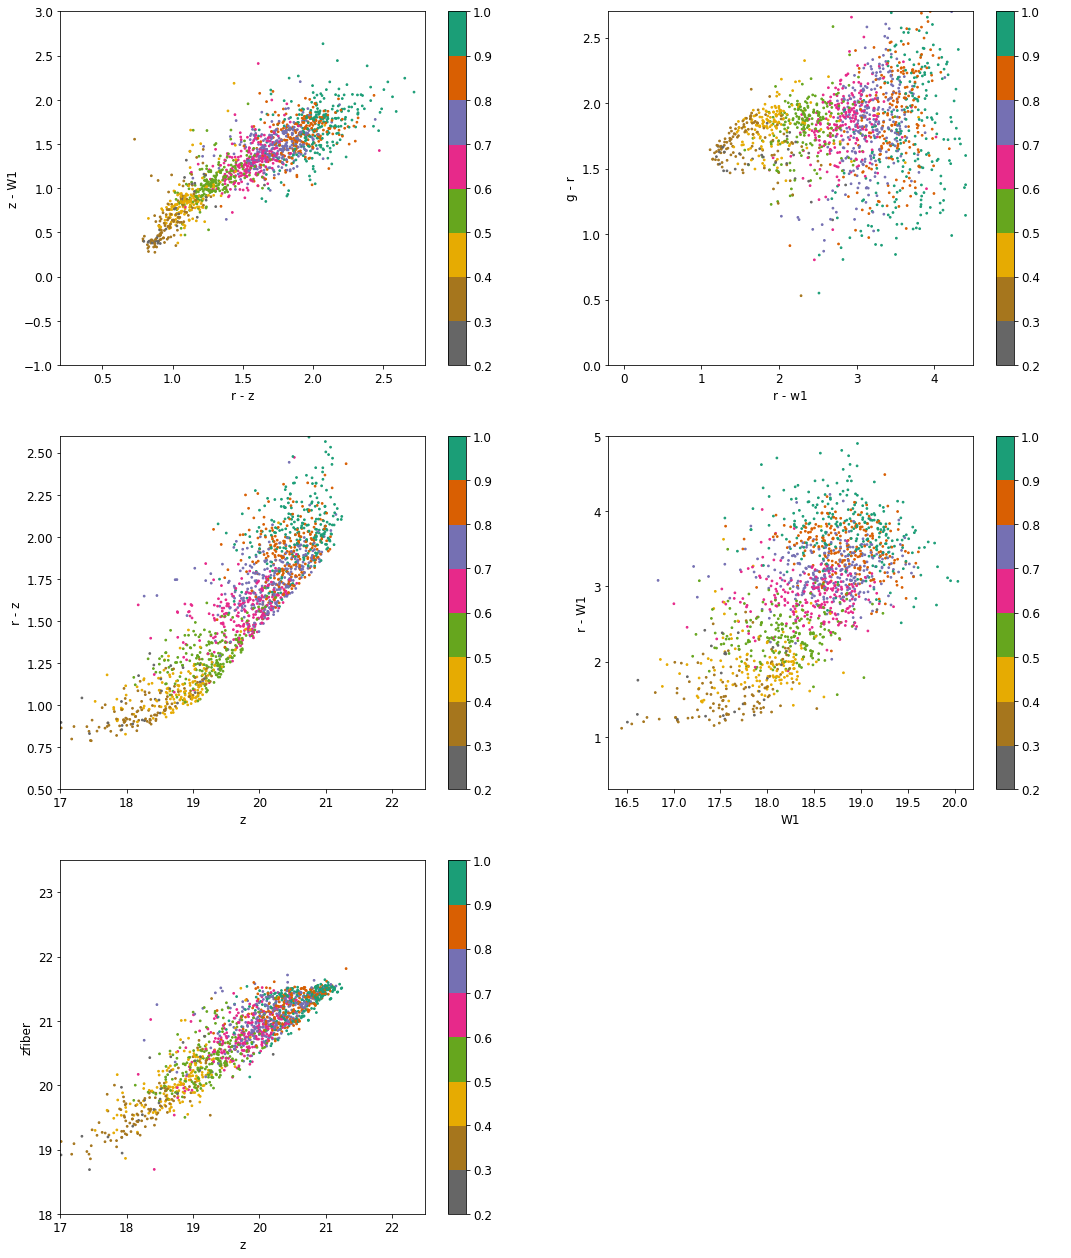

In [31]:
mask = lrg_opt & (~mask_star) & mask_zwarn
print(np.sum(mask))
lrg_plot.color_plot_3x2_new(zbest[mask], ms=3)

23


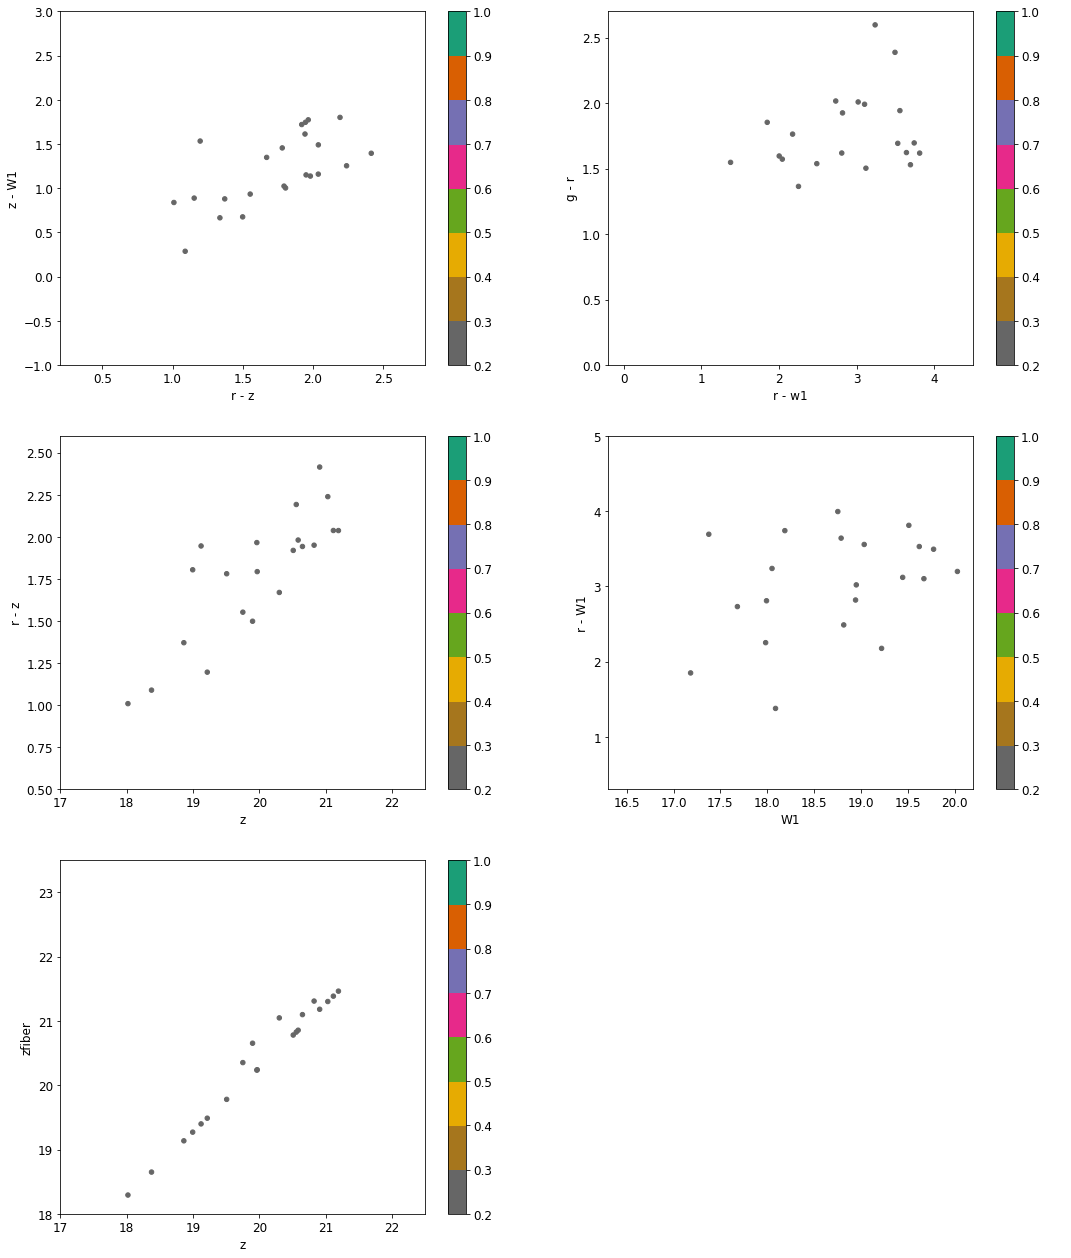

In [32]:
mask = lrg_opt & mask_star & mask_zwarn
print(np.sum(mask))
lrg_plot.color_plot_3x2_new(zbest[mask], ms=20)

5788


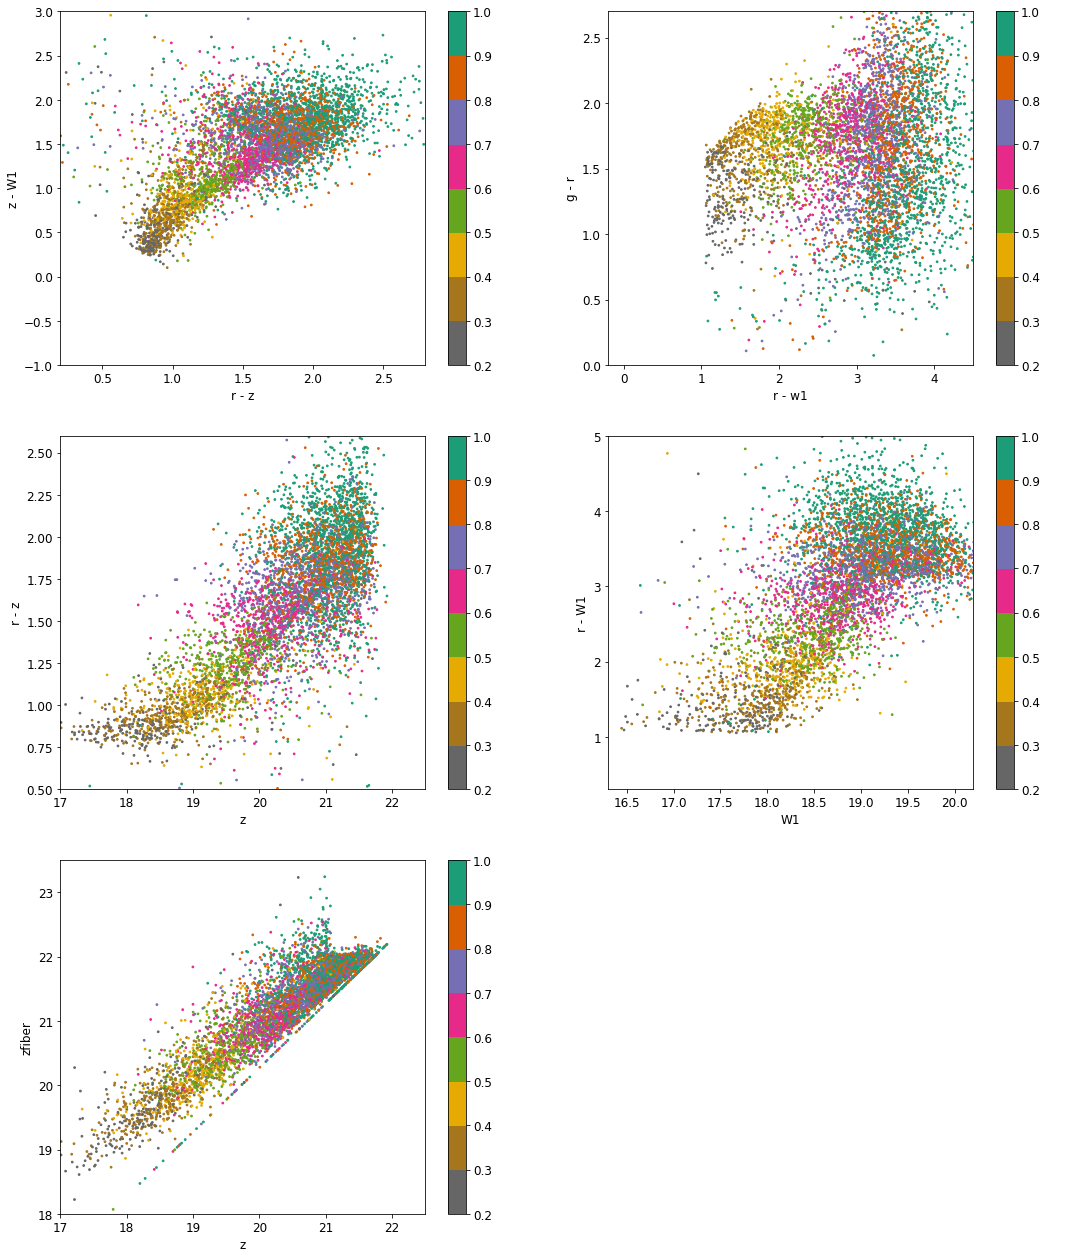

In [33]:
mask = lrg_sv & (~mask_star) & mask_zwarn
print(np.sum(mask))
lrg_plot.color_plot_3x2_new(zbest[mask], ms=3)

105


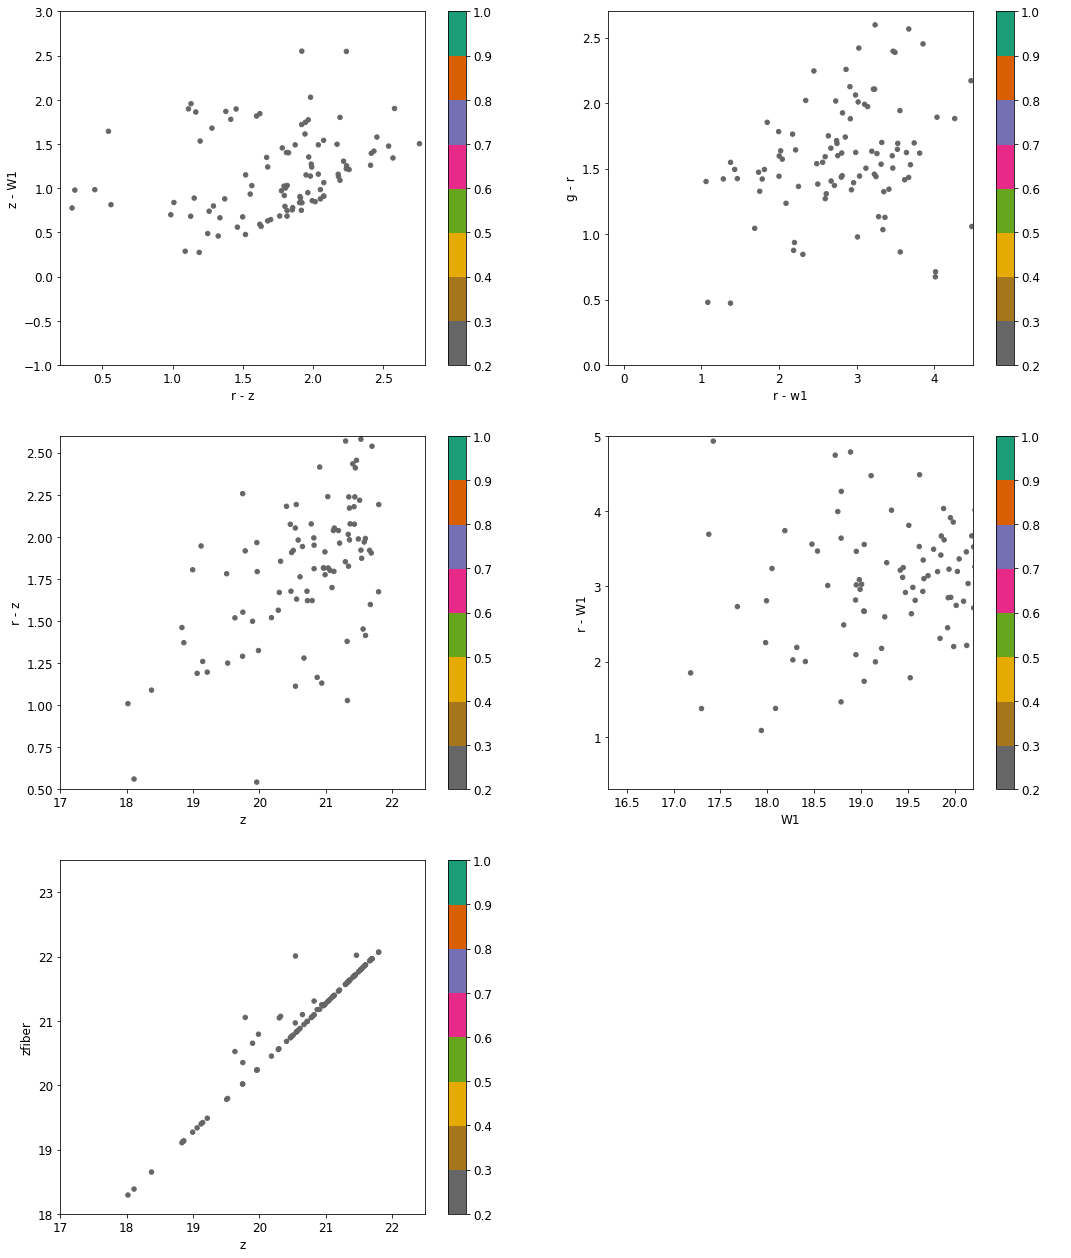

In [34]:
mask = lrg_sv & mask_star & mask_zwarn
print(np.sum(mask))
lrg_plot.color_plot_3x2_new(zbest[mask], ms=20)

In [35]:
mask = lrg_opt & mask_star & mask_zwarn
zbest[mask]

TARGETID,CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,NUMEXP,NUMTILE,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,NUMTARGET,PRIORITY,SUBPRIORITY,OBSCONDITIONS,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,PRIORITY_INIT,NUMOBS_INIT,RELEASE,BRICKID,BRICKNAME,BRICK_OBJID,BLOBDIST,FIBERFLUX_IVAR_G,FIBERFLUX_IVAR_R,FIBERFLUX_IVAR_Z,DESI_TARGET,BGS_TARGET,MWS_TARGET,HPXPIXEL,NUM_ITER,FIBER_X,FIBER_Y,MEAN_DELTA_X,MEAN_DELTA_Y,FIBER_RA,FIBER_DEC,NIGHT,EXPID,MJD,TILEID,COADD_NUMEXP,RMS_DELTA_X,RMS_DELTA_Y,FIRST_NIGHT,LAST_NIGHT,NUM_NIGHT,FIRST_EXPID,LAST_EXPID,NUM_EXPID,FIRST_TILEID,LAST_TILEID,NUM_TILEID,FIRST_FIBER,LAST_FIBER,NUM_FIBER,EXPS,B_DEPTH,R_DEPTH,Z_DEPTH,B_DEPTH_EBVAIR,R_DEPTH_EBVAIR,Z_DEPTH_EBVAIR,ELGTSNR,BGSTSNR,LRGTSNR,QSOTSNR,subset,elgqso_weight,TARGETS,gmag,rmag,zmag,w1mag,w2mag,gmagerr,rmagerr,zmagerr,rfibermag,zfibermag,z_phot
int64,float64,float64,float64,float64,int64,int64,str6,str20,int64,float64,int32,int32,int16,int32,int64,int32,int32,float64,float64,float32,float32,float32,float32,int64,uint8,str3,float32,float32,int16,int32,float64,int32,str4,float32,float32,float32,float32,float32,float32,int64,str2,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,str1,int64,int64,int64,int64,int64,int32,int32,str8,int32,float32,float32,float32,float32,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,int32,int32,float64,int32,int16,float64,float64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,str167,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str8,float64,str7,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64
39628521877803343,44687.81350963001,1825.350902935285 .. 0.0,4.97729373785413e-05,1.448325414322537e-06,0,7903,STAR,K,5,55854.19072539921,0,1,9,63,9063,4699,0,155.57000866252025,31.899813898592566,0.0,0.0,2020.9651,5400.0,1297036692808663165,1,TGT,-118.265236,-103.82372,16959,3400,0.763435023282448,5,PSF,1.0696349,6.8484125,20.612947,640.93097,96.68544,1.2550247,0,,0.0,0.0,0.0,0.0,0.020030547,84.6366,72.66847,0.8324229,5.329646,16.041634,5.610833,19.142714,48.659805,128,0.0,0.0,0.0,0.0,S,1297036692808663165,1048592,0,3400,1,9010,506118,1554p320,4431,1e+20,1e+20,1e+20,1e+20,0,0,0,999999,2,-118.253,-103.8,0.0015000000000000002,0.00033333333333333365,155.5700015079964,31.899815257673268,20201219,68858,59203.43642803,80622,6,0.005369667897862337,0.005066228051190221,20201219,20201221,2,68858,69269,6,80622,80622,1,4699,4699,1,"68858,68859,68879,69267,69268,69269",6307.9998779296875,5790.699890136719,6188.199951171875,5514.6220703125,5283.7022705078125,5882.4495849609375,5380.721243321896,81833.24011230469,457.54018557071686,727.068065404892,deep,1.0,QSO+LRG,22.42691,20.411026,19.21465,17.681105,17.846634,0.036928255,0.014850106,0.043304574,20.683254,19.486877,4.97729373785413e-05
39633314159526917,20785.53205641708,-89.83330773561546 .. 0.0,-3.7063443286889076e-05,1.233717291711885e-05,0,7929,STAR,M,5,1179.6059589872639,0,1,0,449,449,451,0,106.81349266557604,54.61804018709363,0.0,0.0,2020.9487,5400.0,3407977,1,TGT,-9.329903,-373.5488,0,3200,0.7780769510031845,1,PSF,0.1154483,0.54892427,3.5854523,718.0813,268.2835,105.74376,0,,0.0,0.0,0.0,0.0,0.059458654,14.150066,1.5690776,0.08992072,0.42754775,2.7926478,0.090254046,0.4285814,2.794724,256,0.0,0.0,0.0,0.0,N,3407977,0,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,-9.367,-373.508,0.0008571428571428572,-0.0002142857142857143,106

In [36]:
mask = lrg_opt & mask_zwarn
mask &= zbest['MASKBITS'] & 2**8>0
print(np.sum(mask))
zbest[mask]

30


TARGETID,CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,NUMEXP,NUMTILE,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,NUMTARGET,PRIORITY,SUBPRIORITY,OBSCONDITIONS,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,PRIORITY_INIT,NUMOBS_INIT,RELEASE,BRICKID,BRICKNAME,BRICK_OBJID,BLOBDIST,FIBERFLUX_IVAR_G,FIBERFLUX_IVAR_R,FIBERFLUX_IVAR_Z,DESI_TARGET,BGS_TARGET,MWS_TARGET,HPXPIXEL,NUM_ITER,FIBER_X,FIBER_Y,MEAN_DELTA_X,MEAN_DELTA_Y,FIBER_RA,FIBER_DEC,NIGHT,EXPID,MJD,TILEID,COADD_NUMEXP,RMS_DELTA_X,RMS_DELTA_Y,FIRST_NIGHT,LAST_NIGHT,NUM_NIGHT,FIRST_EXPID,LAST_EXPID,NUM_EXPID,FIRST_TILEID,LAST_TILEID,NUM_TILEID,FIRST_FIBER,LAST_FIBER,NUM_FIBER,EXPS,B_DEPTH,R_DEPTH,Z_DEPTH,B_DEPTH_EBVAIR,R_DEPTH_EBVAIR,Z_DEPTH_EBVAIR,ELGTSNR,BGSTSNR,LRGTSNR,QSOTSNR,subset,elgqso_weight,TARGETS,gmag,rmag,zmag,w1mag,w2mag,gmagerr,rmagerr,zmagerr,rfibermag,zfibermag,z_phot
int64,float64,float64,float64,float64,int64,int64,str6,str20,int64,float64,int32,int32,int16,int32,int64,int32,int32,float64,float64,float32,float32,float32,float32,int64,uint8,str3,float32,float32,int16,int32,float64,int32,str4,float32,float32,float32,float32,float32,float32,int64,str2,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,str1,int64,int64,int64,int64,int64,int32,int32,str8,int32,float32,float32,float32,float32,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,int32,int32,float64,int32,int16,float64,float64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,str167,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str8,float64,str7,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64
39627847635046841,21411.44572287053,64.4712095182542 .. -5.149580734684673,0.765341413003753,0.00010211364911115658,0,7930,GALAXY,,10,649.2647235170007,0,1,3,37,3037,1526,0,149.7350904464339,2.411861469680825,0.0,0.0,2020.9487,5400.0,41943081,1,TGT,93.671005,50.285503,0,3200,0.044915002087303035,1,DEV,0.968269,2.3265707,9.5674095,209.87999,99.18268,17.690256,0,,0.0,0.0,0.0,0.0,0.02094013,25.125689,22.831797,0.27969474,0.67205465,2.7636476,0.27981606,0.67231166,2.7639813,2816,4.0,1.624775,-0.13368683,-0.26354256,S,41943081,0,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,93.664,50.293,0.0028461538461538455,-0.0008461538461538464,149.73507881007697,2.411857994304201,20201214,67781,59198.43399897,80609,13,0.007671124679351381,0.009587652315508574,20201214,20201217,4,67781,68490,13,80609,80609,1,1526,1526,1,"67781,67783,68063,68064,68065,68334,68336,68337,68338,68339,68340,68489,68490",10984.599914550781,7969.700042724609,7215.700103759766,8965.964721679688,7011.713165283203,6717.894836425781,6665.289429366589,124337.3544921875,649.6725469827652,1087.929132938385,deep,1.0,QSO+LRG,22.53501,21.58321,20.048014,18.999704,19.10365,0.07128833,0.04315845,0.024850698,22.931488,21.396294,0.765341413003753
39627847668598611,17619.173988752067,132.68604522560787 .. 5.368766817477418,0.7488449584526631,9.226397735939407e-05,0,7922,GALAXY,,10,1025.3484944179654,0,1,7,494,7494,3813,0,151.5972616617636,2.460801804109923,0.0,0.0,2020.9487,5400.0,41943081,1,TGT,-372.34732,64.0592,0,3200,0.005504482318442028,1,DEV,0.42345166,1.9141861,9.119796,398.44092,189.70227,25.340734,0,,0.0,0.0,0.0,0.0,0.04254677,22.412022,4.0387583,0.13183679,0.5959597,2.839343,0.13682634,0.60204005,2.8502398,768,4.0,1.4316254,-0.14719439,-0.23938365,S,41943081,0,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,-372.236,63.98

----------
# Delta-chi-square

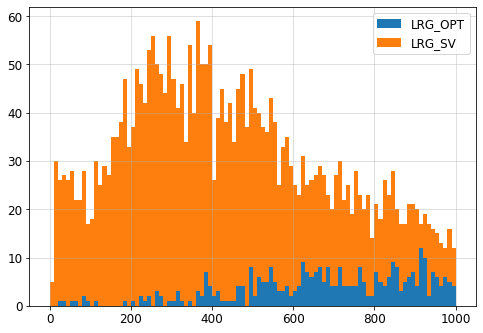

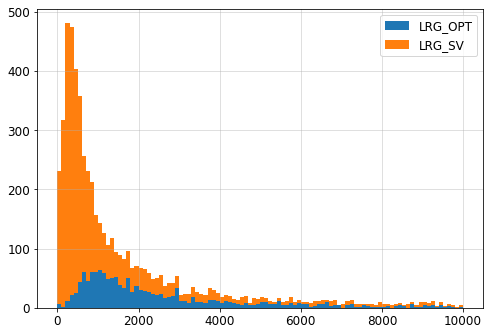

In [37]:
plt.figure(figsize=(8, 5.5))
plt.hist(zbest['DELTACHI2'][lrg_opt & mask_zwarn], 100, range=(0, 1000.), label='LRG_OPT', zorder=2)
plt.hist(zbest['DELTACHI2'][lrg_sv & mask_zwarn], 100, range=(0, 1000.), label='LRG_SV', zorder=1)
# plt.xlabel('redshift')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

plt.figure(figsize=(8, 5.5))
plt.hist(zbest['DELTACHI2'][lrg_opt & mask_zwarn], 100, range=(0, 10000.), label='LRG_OPT', zorder=2)
plt.hist(zbest['DELTACHI2'][lrg_sv & mask_zwarn], 100, range=(0, 10000.), label='LRG_SV', zorder=1)
# plt.xlabel('redshift')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

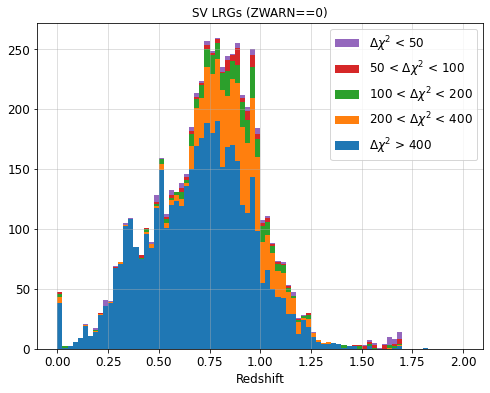

In [38]:
plt.figure(figsize=(8, 6))
mask_dchi2 = zbest['DELTACHI2']>0
plt.hist(zbest['Z'][lrg_sv & mask_zwarn & mask_dchi2], bins=80, color='C4', range=(0, 2.0), label='$\Delta \chi^2$ < 50')
mask_dchi2 = zbest['DELTACHI2']>50
plt.hist(zbest['Z'][lrg_sv & mask_zwarn & mask_dchi2], bins=80, color='C3', range=(0, 2.0), label='50 < $\Delta \chi^2$ < 100')
mask_dchi2 = zbest['DELTACHI2']>100
plt.hist(zbest['Z'][lrg_sv & mask_zwarn & mask_dchi2], bins=80, color='C2', range=(0, 2.0), label='100 < $\Delta \chi^2$ < 200')
mask_dchi2 = zbest['DELTACHI2']>200
plt.hist(zbest['Z'][lrg_sv & mask_zwarn & mask_dchi2], bins=80, color='C1', range=(0, 2.0), label='200 < $\Delta \chi^2$ < 400')
mask_dchi2 = zbest['DELTACHI2']>400
plt.hist(zbest['Z'][lrg_sv & mask_zwarn & mask_dchi2], bins=80, color='C0', range=(0, 2.0), label='$\Delta \chi^2$ > 400')
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.title('SV LRGs (ZWARN==0)')
# plt.ylim(0, 120)
plt.show()

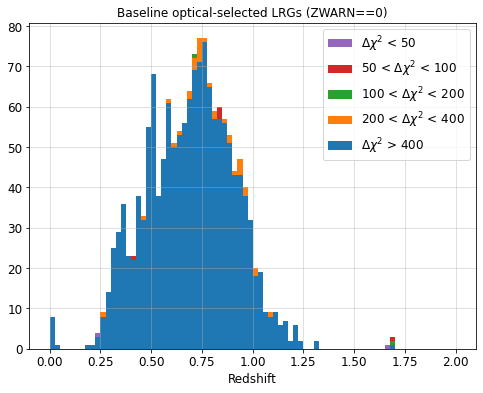

In [39]:
plt.figure(figsize=(8, 6))
mask_dchi2 = zbest['DELTACHI2']>0
plt.hist(zbest['Z'][lrg_opt & mask_zwarn & mask_dchi2], bins=80, color='C4', range=(0, 2.0), label='$\Delta \chi^2$ < 50')
mask_dchi2 = zbest['DELTACHI2']>50
plt.hist(zbest['Z'][lrg_opt & mask_zwarn & mask_dchi2], bins=80, color='C3', range=(0, 2.0), label='50 < $\Delta \chi^2$ < 100')
mask_dchi2 = zbest['DELTACHI2']>100
plt.hist(zbest['Z'][lrg_opt & mask_zwarn & mask_dchi2], bins=80, color='C2', range=(0, 2.0), label='100 < $\Delta \chi^2$ < 200')
mask_dchi2 = zbest['DELTACHI2']>200
plt.hist(zbest['Z'][lrg_opt & mask_zwarn & mask_dchi2], bins=80, color='C1', range=(0, 2.0), label='200 < $\Delta \chi^2$ < 400')
mask_dchi2 = zbest['DELTACHI2']>400
plt.hist(zbest['Z'][lrg_opt & mask_zwarn & mask_dchi2], bins=80, color='C0', range=(0, 2.0), label='$\Delta \chi^2$ > 400')
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.title('Baseline optical-selected LRGs (ZWARN==0)')
# plt.ylim(0, 120)
plt.show()

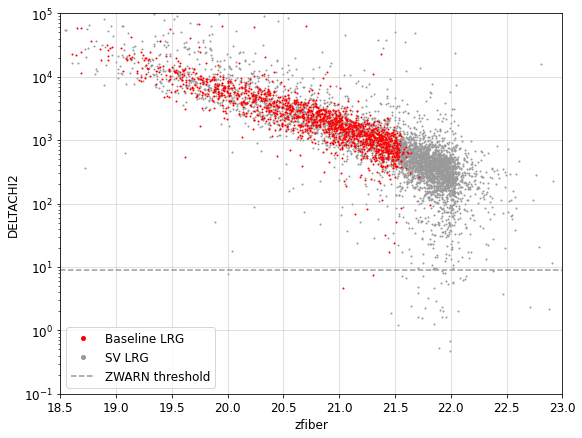

Add ZWARN cut:


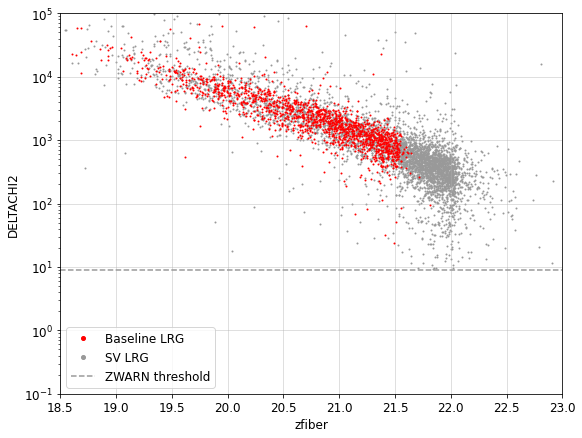

In [40]:
plt.figure(figsize=(9, 7))
plt.plot(zbest['zfibermag'][lrg_opt], zbest['DELTACHI2'][lrg_opt], 'r.', ms=2, alpha=1, label='Baseline LRG', zorder=10)
plt.plot(zbest['zfibermag'][(~lrg_opt) & lrg_sv], zbest['DELTACHI2'][(~lrg_opt) & lrg_sv], '.', color='0.6', ms=2, alpha=1, label='SV LRG', zorder=0)
plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('zfiber')
plt.ylabel('DELTACHI2')
plt.axis([18.5, 23., .1, 100000])
plt.legend(markerscale=4)
plt.grid(alpha=0.5)
plt.show()

print('Add ZWARN cut:')
plt.figure(figsize=(9, 7))
plt.plot(zbest['zfibermag'][lrg_opt & mask_zwarn], zbest['DELTACHI2'][lrg_opt & mask_zwarn], 'r.', ms=2, alpha=1, label='Baseline LRG', zorder=10)
plt.plot(zbest['zfibermag'][(~lrg_opt) & lrg_sv & mask_zwarn], zbest['DELTACHI2'][(~lrg_opt) & lrg_sv & mask_zwarn], '.', color='0.6', ms=2, alpha=1, label='SV LRG', zorder=0)
plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('zfiber')
plt.ylabel('DELTACHI2')
plt.axis([18.5, 23., .1, 100000])
plt.legend(markerscale=4)
plt.grid(alpha=0.5)
plt.show()

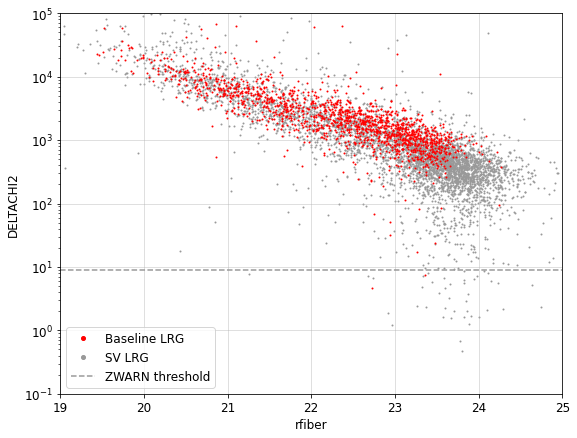

In [41]:
plt.figure(figsize=(9, 7))
plt.plot(zbest['rfibermag'][lrg_opt], zbest['DELTACHI2'][lrg_opt], 'r.', ms=2, alpha=1, label='Baseline LRG', zorder=10)
plt.plot(zbest['rfibermag'][(~lrg_opt) & lrg_sv], zbest['DELTACHI2'][(~lrg_opt) & lrg_sv], '.', color='0.6', ms=2, alpha=1, label='SV LRG', zorder=0)
plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('rfiber')
plt.ylabel('DELTACHI2')
plt.axis([19, 25, .1, 100000])
plt.legend(markerscale=4)
plt.grid(alpha=0.5)
plt.show()

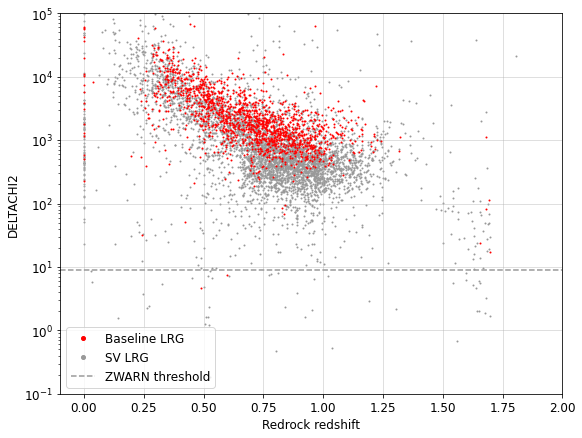

In [42]:
plt.figure(figsize=(9, 7))
plt.plot(zbest['Z'][lrg_opt], zbest['DELTACHI2'][lrg_opt], 'r.', ms=2, alpha=1, label='Baseline LRG', zorder=10)
plt.plot(zbest['Z'][(~lrg_opt) & lrg_sv], zbest['DELTACHI2'][(~lrg_opt) & lrg_sv], '.', color='0.6', ms=2, alpha=1, label='SV LRG', zorder=1)
plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('Redrock redshift')
plt.ylabel('DELTACHI2')
plt.axis([-0.1, 2, .1, 100000])
plt.legend(markerscale=4, loc='lower left')
plt.grid(alpha=0.5)
plt.show()